   participant_id      form_name form_size progress_bar  completion_time_ms  \
0              44  large_without     large      without              144864   
1              47  large_without     large      without               29246   
2              49  large_without     large      without               21543   
3               7  large_without     large      without               57812   
4              74  large_without     large      without              113673   

   scanpath_length  saccade_velocity  fixation_count  \
0    187309.979585          1.432431             120   
1     19772.222676          0.775528               7   
2     16365.945265          0.823942               4   
3     45551.910363          0.866265              13   
4    127089.518763          1.352274              76   

   avg_fixation_duration_ms  progress_fixations  progress_fixation_time_ms  \
0                105.575000                 146                    15546.0   
1                186.000000     

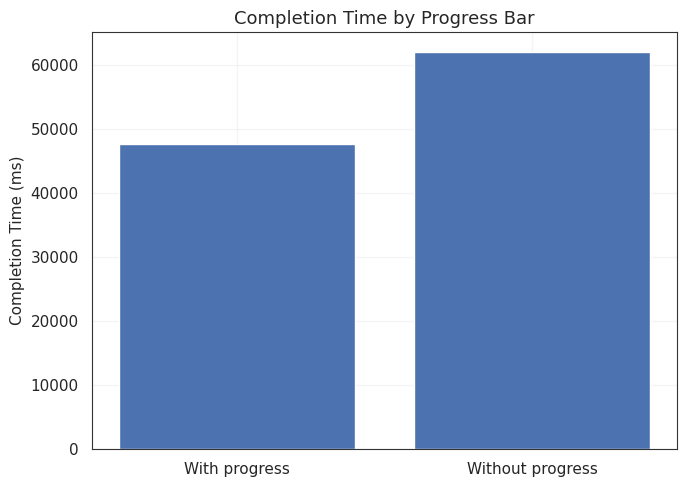

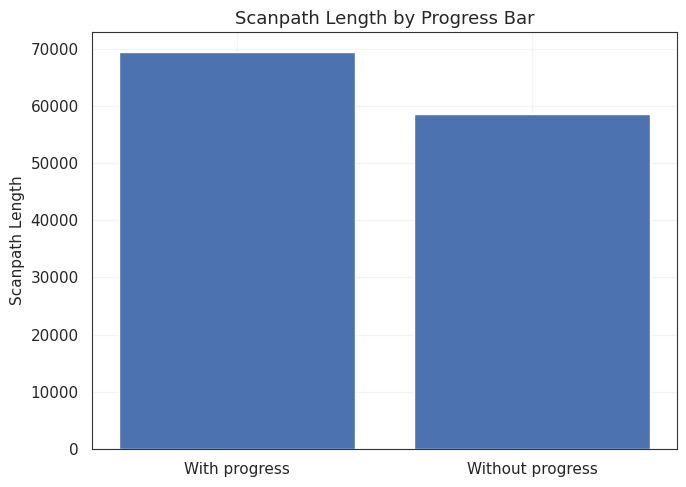

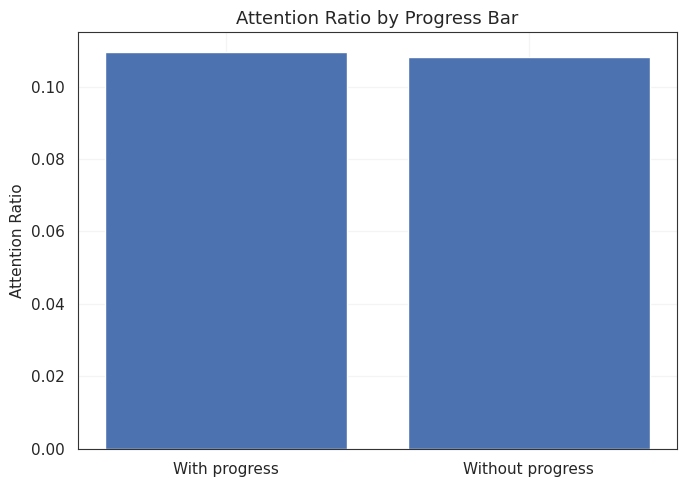

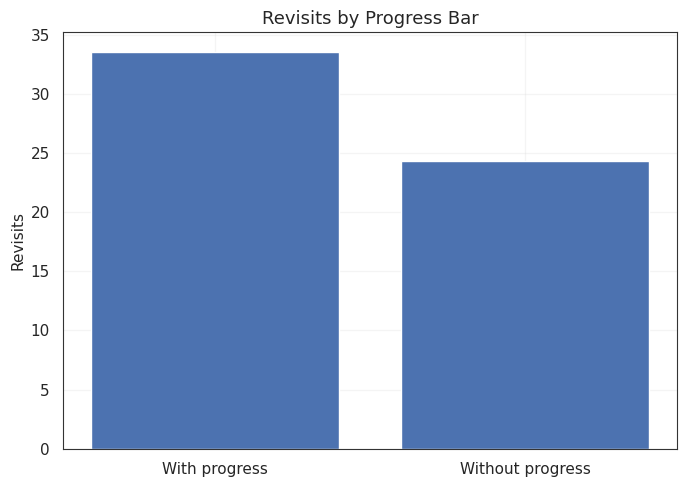

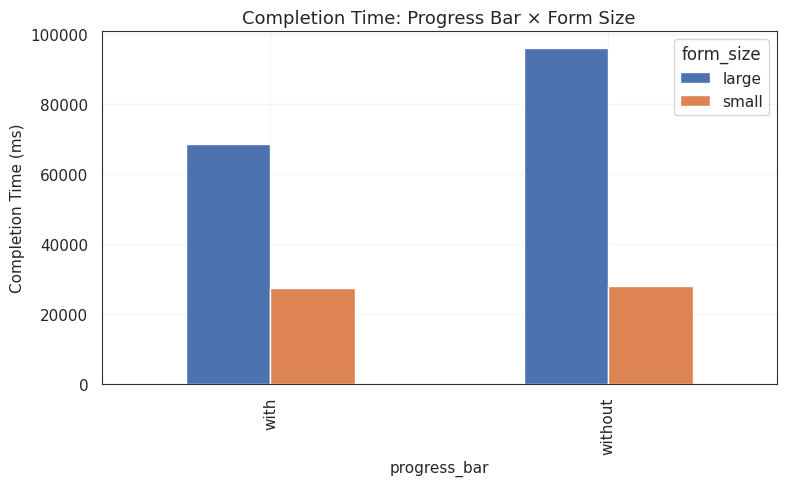

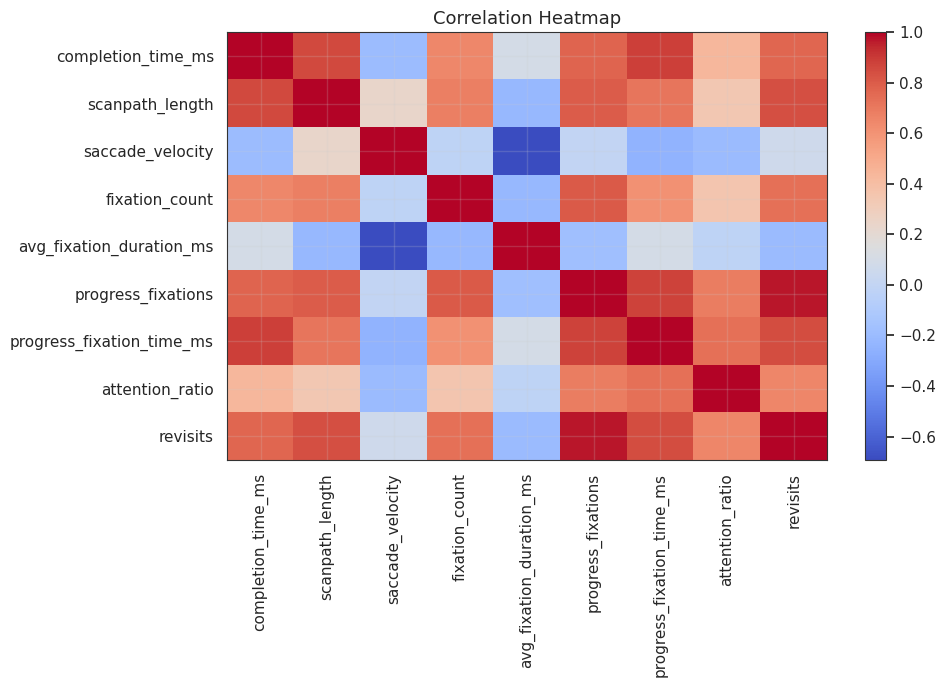


АНАЛИЗ ЗАВЕРШЁН

Сохранён файл:
descriptive_statistics.csv


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

import statsmodels.api as sm
from statsmodels.formula.api import ols

# =========================================================
# СТИЛЬ ГРАФИКОВ
# =========================================================

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#333333',
    'axes.linewidth': 0.8,
    'grid.alpha': 0.2,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11
})

# =========================================================
# ЗАГРУЗКА ДАННЫХ
# =========================================================

df = pd.read_csv('/content/drive/MyDrive/eye_tracking_metrics.csv')

print(df.head())

# =========================================================
# РАЗДЕЛЕНИЕ ГРУПП
# =========================================================

with_progress = df[df['progress_bar'] == 'with']
without_progress = df[df['progress_bar'] == 'without']

# =========================================================
# МЕТРИКИ
# =========================================================

metrics = [
    'completion_time_ms',
    'scanpath_length',
    'saccade_velocity',
    'fixation_count',
    'avg_fixation_duration_ms',
    'progress_fixations',
    'progress_fixation_time_ms',
    'attention_ratio',
    'revisits'
]

# =========================================================
# СТАТИСТИКА
# =========================================================

print('\n==============================')
print('DESCRIPTIVE STATISTICS')
print('==============================')

group_stats = df.groupby(
    ['progress_bar', 'form_size']
)[metrics].agg(['mean', 'std', 'median'])

print(group_stats)

# =========================================================
# T-TEST
# =========================================================

print('\n==============================')
print('T-TEST')
print('==============================')

for metric in metrics:

    group1 = with_progress[metric]
    group2 = without_progress[metric]

    stat, p = ttest_ind(group1, group2, nan_policy='omit')

    print(f'\n{metric}')
    print(f't-statistic: {stat:.4f}')
    print(f'p-value: {p:.4f}')

    if p < 0.05:
        print('STATISTICALLY SIGNIFICANT')
    else:
        print('NOT significant')

# =========================================================
# MANN-WHITNEY
# =========================================================

print('\n==============================')
print('MANN-WHITNEY U TEST')
print('==============================')

for metric in metrics:

    group1 = with_progress[metric]
    group2 = without_progress[metric]

    stat, p = mannwhitneyu(group1, group2, alternative='two-sided')

    print(f'\n{metric}')
    print(f'U-statistic: {stat:.4f}')
    print(f'p-value: {p:.4f}')

# =========================================================
# ANOVA
# =========================================================

print('\n==============================')
print('TWO-WAY ANOVA')
print('==============================')

anova_metrics = [
    'completion_time_ms',
    'scanpath_length',
    'revisits',
    'attention_ratio'
]

for metric in anova_metrics:

    print(f'\n========== {metric} ==========')

    model = ols(
        f'{metric} ~ C(progress_bar) + C(form_size) + C(progress_bar):C(form_size)',
        data=df
    ).fit()

    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)

# =========================================================
# ФУНКЦИЯ СТОЛБЧАТЫХ ГРАФИКОВ (БЕЗ ОШИБОК)
# =========================================================

def bar_plot(metric, title, ylabel):

    means = [
        with_progress[metric].mean(),
        without_progress[metric].mean()
    ]

    labels = ['With progress', 'Without progress']

    plt.figure(figsize=(7, 5))

    plt.bar(labels, means)

    plt.title(title)
    plt.ylabel(ylabel)

    plt.grid(axis='y', alpha=0.2)

    plt.tight_layout()
    plt.show()

# =========================================================
# ГРАФИКИ
# =========================================================

bar_plot(
    'completion_time_ms',
    'Completion Time by Progress Bar',
    'Completion Time (ms)'
)

bar_plot(
    'scanpath_length',
    'Scanpath Length by Progress Bar',
    'Scanpath Length'
)

bar_plot(
    'attention_ratio',
    'Attention Ratio by Progress Bar',
    'Attention Ratio'
)

bar_plot(
    'revisits',
    'Revisits by Progress Bar',
    'Revisits'
)

# =========================================================
# FORM SIZE × PROGRESS BAR
# =========================================================

metric = 'completion_time_ms'

groups = df.groupby(['progress_bar', 'form_size'])[metric].mean().unstack()

groups.plot(kind='bar', figsize=(8, 5))

plt.title('Completion Time: Progress Bar × Form Size')
plt.ylabel('Completion Time (ms)')
plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

# =========================================================
# КОРРЕЛЯЦИИ
# =========================================================

plt.figure(figsize=(10, 7))

correlation = df[metrics].corr()

plt.imshow(correlation, cmap='coolwarm', aspect='auto')

plt.colorbar()

plt.xticks(range(len(metrics)), metrics, rotation=90)
plt.yticks(range(len(metrics)), metrics)

plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

# =========================================================
# СОХРАНЕНИЕ
# =========================================================

group_stats.to_csv('descriptive_statistics.csv')

print('\n================================')
print('АНАЛИЗ ЗАВЕРШЁН')
print('================================')

print('\nСохранён файл:')
print('descriptive_statistics.csv')